In [1]:
%pip install thinkdsp-kim pandas scipy matplotlib numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
sys.path.append('../../code')

import os
import numpy as np
import matplotlib.pyplot as plt

import thinkdsp
import thinkplot

from thinkdsp import read_wave, decorate
from IPython.display import display, Audio

In [3]:
filename = '../../code/92002__jcveliz__violin-origional.wav'

wave = read_wave(filename)
wave.normalize()

wave.make_audio()

График исходного сигнала

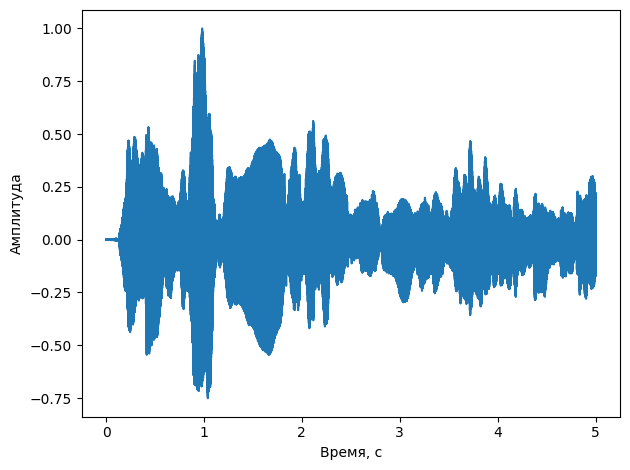

In [4]:
wave.plot()
decorate(xlabel='Время, с', ylabel='Амплитуда')

На графике показан исходный звуковой сигнал скрипки. Видно, что амплитуда сигнала изменяется во времени. Для анализа спектра выберем участок, где высота звука примерно постоянна.

Выделение полусекундного сегмента

Был выбран фрагмент сигнала длительностью 0.5 с, начиная с момента 1.2 с. 

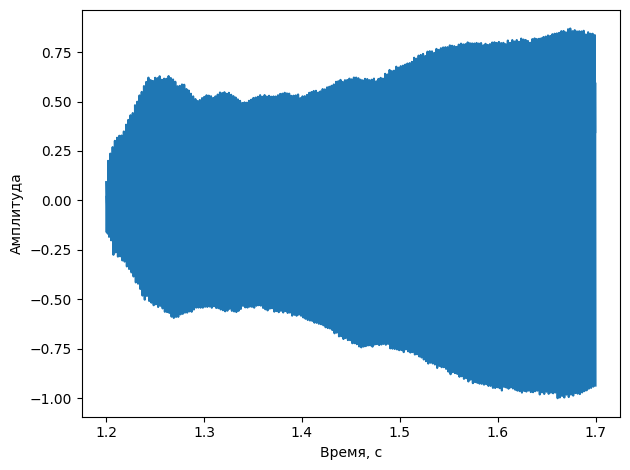

In [5]:
start = 1.2
duration = 0.5

segment = wave.segment(start=start, duration=duration)
segment.normalize()

segment.plot()
decorate(xlabel='Время, с', ylabel='Амплитуда')

Спектр выбранного сегмента

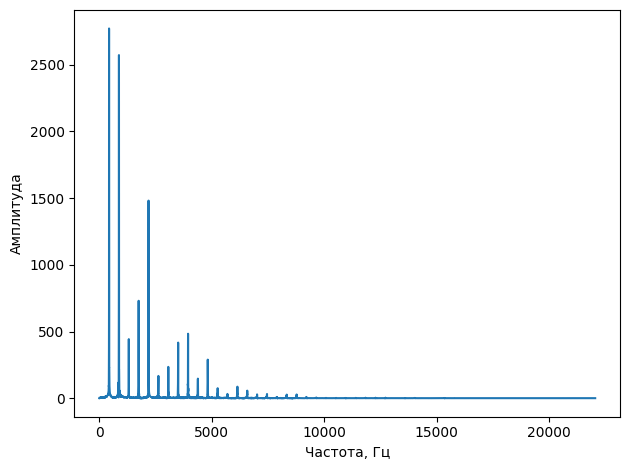

In [6]:
spectrum = segment.make_spectrum()

spectrum.plot()
decorate(xlabel='Частота, Гц', ylabel='Амплитуда')

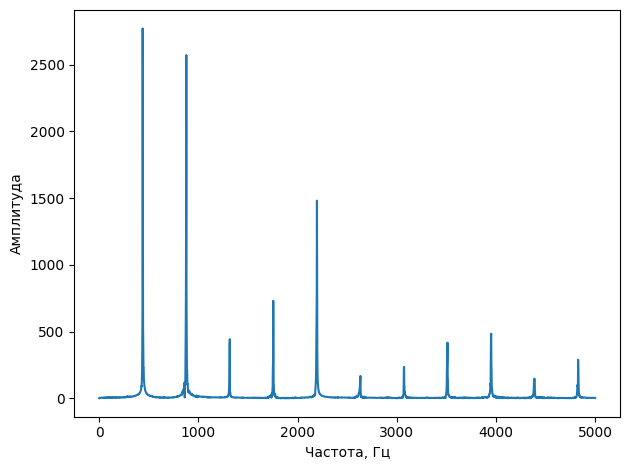

In [7]:
spectrum.plot(high=5000)
decorate(xlabel='Частота, Гц', ylabel='Амплитуда')

В спектре видны пики амплитуды на отдельных частотах. Самый низкий выраженный пик соответствует основной частоте звука. Остальные пики находятся на более высоких частотах и являются гармониками.

Тембр звука связан с гармонической структурой спектра. Если бы звук состоял только из одной частоты, он был бы похож на простой чистый тон. Реальный звук скрипки сложнее - кроме основной частоты, в нём присутствуют гармоники. Именно они делают звук более насыщенным и позволяют отличать скрипку от других инструментов, даже если они играют ноту той же высоты.

Фильтр нижних частот low_pass

Создадим копию спектра, где частоты выше 1000 Гц будут ослаблены (cutoff=1000) и будут уменьшены примерно до 1% от исходного значения (factor=0.01).

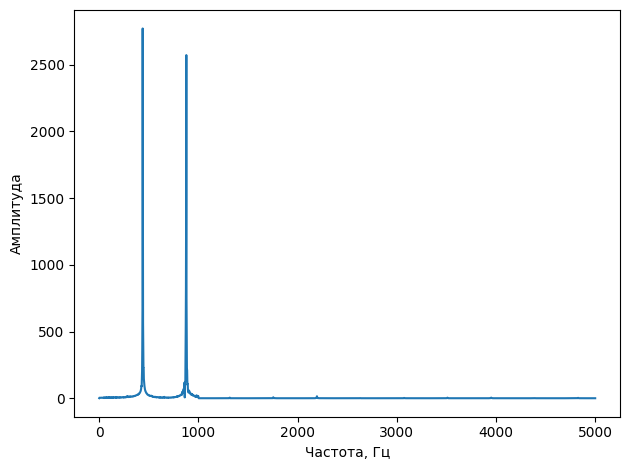

In [8]:
low_spectrum = segment.make_spectrum()
low_spectrum.low_pass(cutoff=1000, factor=0.01)

low_spectrum.plot(high=5000)
decorate(xlabel='Частота, Гц', ylabel='Амплитуда')

Спектр -> сигнал

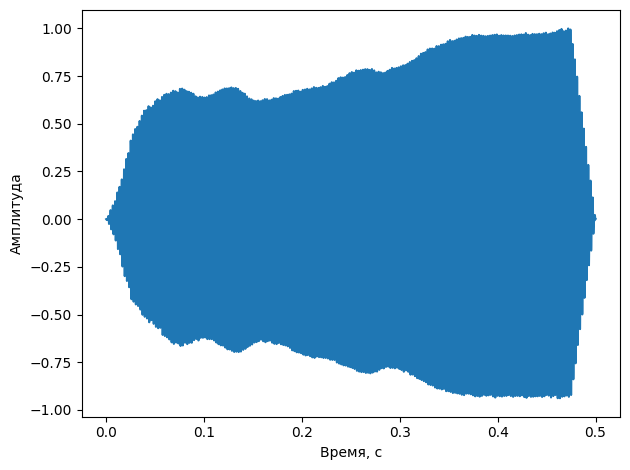

In [9]:
low_wave = low_spectrum.make_wave()
low_wave.normalize()
low_wave.apodize()

low_wave.plot()
decorate(xlabel='Время, с', ylabel='Амплитуда')

In [10]:
low_wave.make_audio()

In [11]:
low_wave.write('violin_low_pass.wav')

Writing violin_low_pass.wav


После применения фильтра нижних частот высокочастотные гармоники были ослаблены. Звук стал более глухим.

Фильтр верхних частот high_pass

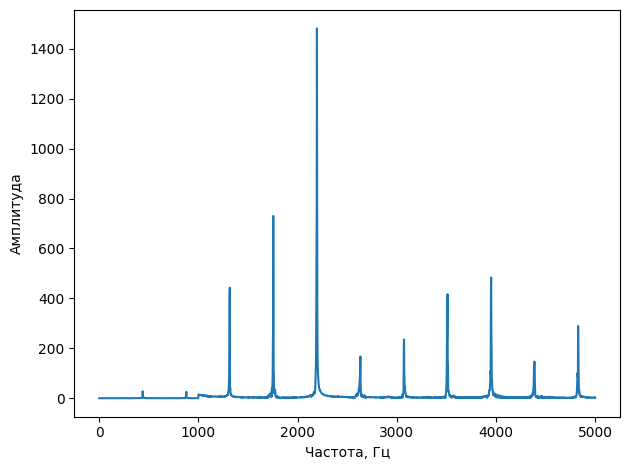

In [12]:
high_spectrum = segment.make_spectrum()
high_spectrum.high_pass(cutoff=1000, factor=0.01)

high_spectrum.plot(high=5000)
decorate(xlabel='Частота, Гц', ylabel='Амплитуда')

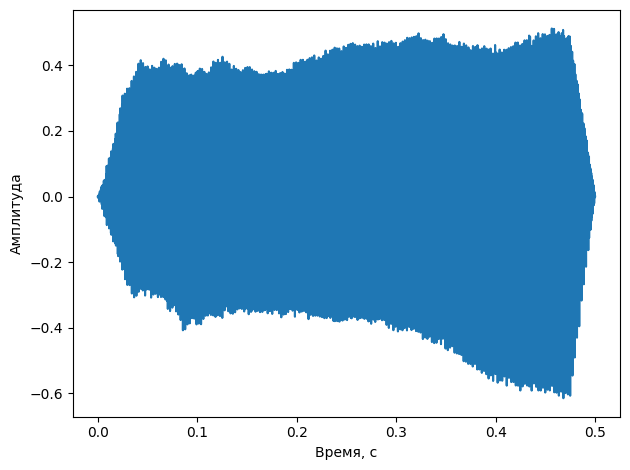

In [13]:
high_wave = high_spectrum.make_wave()
high_wave.normalize()
high_wave.apodize()

high_wave.plot()
decorate(xlabel='Время, с', ylabel='Амплитуда')

In [14]:
high_wave.make_audio()

In [15]:
high_wave.write('violin_high_pass.wav')

Writing violin_high_pass.wav


После применения фильтра верхних частот низкие частоты, включая основную частоту, были ослаблены. Звук стал более тонким и резким.

Полосно-заграждающий фильтр band_stop

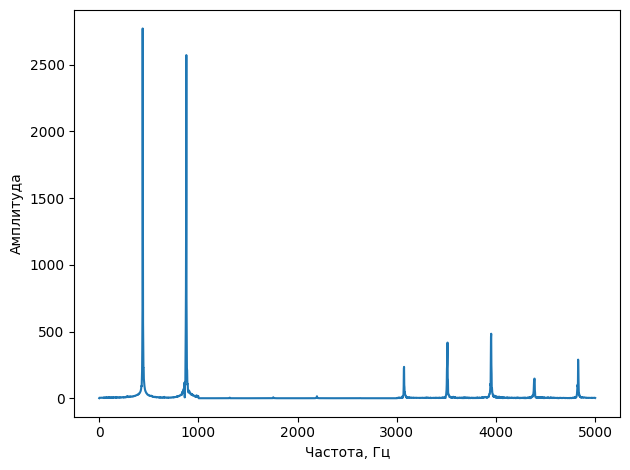

In [18]:
band_spectrum = segment.make_spectrum()
band_spectrum.band_stop(low_cutoff=1000, high_cutoff=3000, factor=0.01)

band_spectrum.plot(high=5000)
decorate(xlabel='Частота, Гц', ylabel='Амплитуда')

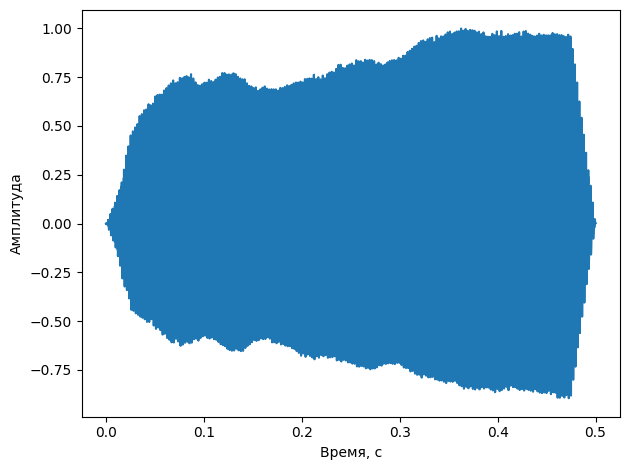

In [19]:
band_wave = band_spectrum.make_wave()
band_wave.normalize()
band_wave.apodize()

band_wave.plot()
decorate(xlabel='Время, с', ylabel='Амплитуда')

In [20]:
band_wave.make_audio()

In [21]:
band_wave.write('violin_band_stop.wav')

Writing violin_band_stop.wav


Полосно-заграждающий фильтр ослабил частоты в диапазоне от 1000 до 3000 Гц. В результате часть гармоник была удалена из спектра. Звук изменил тембр: он стал менее насыщенным, так как была подавлена часть частотных составляющих, отвечающих за характерное звучание скрипки.

Сравнение исходного и обработанных спектров

Исходный и low_pass

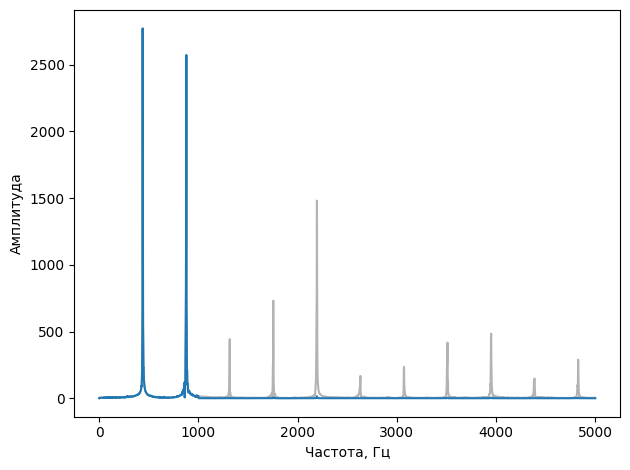

In [22]:
original_spectrum = segment.make_spectrum()
low_spectrum = segment.make_spectrum()
low_spectrum.low_pass(cutoff=1000, factor=0.01)

original_spectrum.plot(high=5000, color='0.7')
low_spectrum.plot(high=5000)
decorate(xlabel='Частота, Гц', ylabel='Амплитуда')

Сравнение исходного спектра и спектра после фильтра нижних частот.

Исходный и high_pass

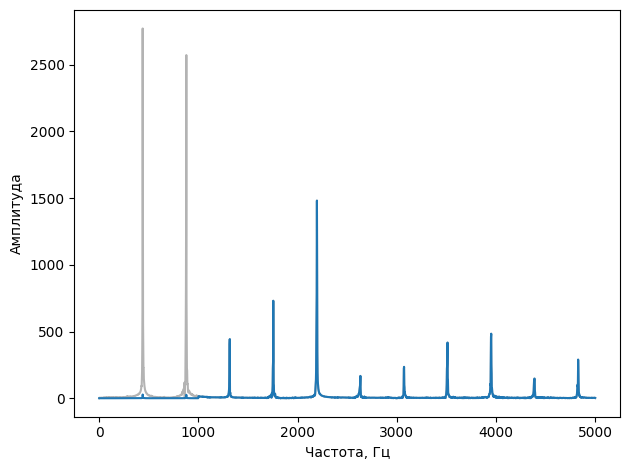

In [23]:
original_spectrum = segment.make_spectrum()
high_spectrum = segment.make_spectrum()
high_spectrum.high_pass(cutoff=1000, factor=0.01)

original_spectrum.plot(high=5000, color='0.7')
high_spectrum.plot(high=5000)
decorate(xlabel='Частота, Гц', ylabel='Амплитуда')

Сравнение исходного спектра и спектра после фильтра верхних частот.

Исходный и band_stop

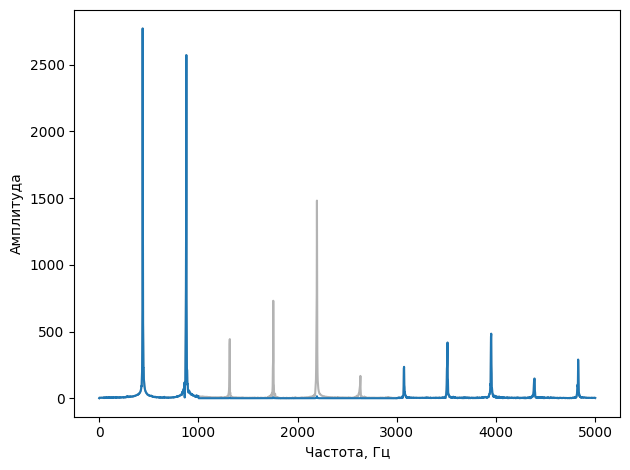

In [24]:
original_spectrum = segment.make_spectrum()
band_spectrum = segment.make_spectrum()
band_spectrum.band_stop(low_cutoff=1000, high_cutoff=3000, factor=0.01)

original_spectrum.plot(high=5000, color='0.7')
band_spectrum.plot(high=5000)
decorate(xlabel='Частота, Гц', ylabel='Амплитуда')

Сравнение исходного спектра и спектра после полосно-заграждающего фильтра.

`low_pass` - Ослабляет частоты выше заданной границы. Звук становится глуше и мягче.
`high_pass` - Ослабляет частоты ниже заданной границы. Звук становится тоньше и резче.
`band_stop` - Ослабляет выбранный диапазон частот. Тембр изменился, звук стал менее насыщенным.

Вывод
В упражнении 1.2 был выбран фрагмент звука скрипки длительностью 0.5 с, на котором высота звука была примерно постоянной. Для этого фрагмента был построен спектр. По спектру видно, что звук содержит основную частоту и набор гармоник. Гармоники определяют тембр звука - чем больше выраженных гармонических составляющих, тем сложнее и насыщеннее звучание.

При применении фильтра нижних частот высокочастотные гармоники были ослаблены, поэтому звук стал более мягким и глухим. При применении фильтра верхних частот были ослаблены низкие частоты, из-за чего звук стал тонким и резким. Полосно-заграждающий фильтр удалил часть гармоник в выбранном диапазоне, поэтому тембр звука заметно изменился. Таким образом, было подтверждено, что изменения в спектре напрямую влияют на воспринимаемое звучание.